# SalesIntel AI — Data Exploration (EDA)

## WHY do EDA before building models?

1. **Understand your data** — you can't model what you don't understand
2. **Spot data quality issues** — missing values, outliers, wrong types
3. **Find patterns** — which features actually correlate with winning/losing?
4. **Inform feature engineering** — what transformations might help the model?
5. **Set a baseline** — what's the win rate? If it's 50%, a model that always says "win" is 50% accurate — your model must beat that.

> **Rule: Never train a model on data you haven't explored first.**

In [1]:
# ============================================================
# IMPORTS & SETUP
# ============================================================
# WHY these libraries?
# - pandas: data manipulation (the SQL of Python)
# - matplotlib + seaborn: visualization (seaborn makes prettier plots with less code)
# - warnings off: seaborn throws deprecation warnings, clutters the notebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# WHY set style? Consistent, clean look across all plots.
# "whitegrid" adds subtle gridlines — helps read values off charts.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)  # Wider plots by default
plt.rcParams["figure.dpi"] = 100

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# ============================================================
# LOAD DATA
# ============================================================
# WHY use relative path from notebook?
# Notebooks run from their own directory, so we go up one level to project root.

deals = pd.read_csv("../data/raw/deals.csv", parse_dates=["created_date", "expected_close_date"])
revenue = pd.read_csv("../data/raw/monthly_revenue.csv", parse_dates=["date"])

print(f"Deals dataset:   {deals.shape[0]} rows x {deals.shape[1]} columns")
print(f"Revenue dataset: {revenue.shape[0]} rows x {revenue.shape[1]} columns")

Deals dataset:   5000 rows x 18 columns
Revenue dataset: 22 rows x 3 columns


## Step 1: First Look at the Data

**Always start here.** Before any analysis, look at:
- What columns exist? What types are they?
- Are there missing values?
- What do a few sample rows look like?

This takes 30 seconds but saves hours of debugging later.

In [3]:
# .head() — Shows first 5 rows. Quick sanity check: do the values look reasonable?
deals.head()

,deal_id,account_name,industry,deal_amount,deal_stage,lead_source,sales_rep,created_date,expected_close_date,days_in_pipeline,num_emails,num_calls,num_meetings,total_activities,num_contacts,competitor_involved,win_probability,outcome
0,D-10000,Vanguard Global,Technology,25893.76,Closed Won,Outbound Cold Call,David Chen,2024-09-29,2024-10-06,7,1,6,3,10,2,1,0.414,Won
1,D-10001,Meridian Group,Education,39293.81,Closed Won,Inbound Website,Carol Williams,2025-03-10,2025-04-05,26,12,1,3,16,4,0,0.583,Won
2,D-10002,Orion Corp,Energy,320989.15,Closed Lost,Trade Show,Frank Okafor,2025-02-04,2025-05-17,102,12,4,3,19,4,0,0.621,Lost
3,D-10003,Prism Partners,Healthcare,66173.49,Closed Won,Partner,Grace Liu,2024-09-30,2024-11-08,39,8,3,1,12,4,0,0.653,Won
4,D-10004,Meridian Technologies,Healthcare,98547.34,Closed Won,Partner,Carol Williams,2024-12-02,2024-12-29,27,7,4,2,13,3,1,0.535,Won


In [4]:
# .info() — Shows column names, types, and non-null counts
# WHAT TO LOOK FOR:
#   - Are dates parsed as datetime64? (not "object"/string)
#   - Any columns with fewer non-null values than total rows? → missing data
#   - Are numeric columns actually numeric? (not stored as strings)
deals.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   deal_id              5000 non-null   str           
 1   account_name         5000 non-null   str           
 2   industry             5000 non-null   str           
 3   deal_amount          5000 non-null   float64       
 4   deal_stage           5000 non-null   str           
 5   lead_source          5000 non-null   str           
 6   sales_rep            5000 non-null   str           
 7   created_date         5000 non-null   datetime64[us]
 8   expected_close_date  5000 non-null   datetime64[us]
 9   days_in_pipeline     5000 non-null   int64         
 10  num_emails           5000 non-null   int64         
 11  num_calls            5000 non-null   int64         
 12  num_meetings         5000 non-null   int64         
 13  total_activities     5000 non-null   int64  

In [5]:
# .describe() — Summary statistics for ALL numeric columns
# WHAT TO LOOK FOR:
#   - min/max: any impossible values? (negative emails? deal_amount = 0?)
#   - mean vs median (50%): if very different → data is skewed
#   - std: how spread out is the data?
deals.describe().round(2)

,deal_amount,created_date,expected_close_date,days_in_pipeline,num_emails,num_calls,num_meetings,total_activities,num_contacts,competitor_involved,win_probability
count,5000.00,5000,5000,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,97092.68,2024-09-30 06:07:46.560000,2024-11-02 07:31:35.040000,33.06,8.02,4.01,2.03,14.05,3.02,0.39,0.57
min,7178.47,2024-01-01 00:00:00,2024-01-08 00:00:00,7.00,0.00,0.00,0.00,3.00,1.00,0.00,0.21
25%,40981.52,2024-05-14 00:00:00,2024-06-16 00:00:00,17.00,6.00,3.00,1.00,11.00,2.00,0.00,0.48
50%,73174.99,2024-10-03 00:00:00,2024-11-06 00:00:00,30.00,8.00,4.00,2.00,14.00,3.00,0.00,0.57
75%,127514.26,2025-02-14 00:00:00,2025-03-21 00:00:00,45.00,10.00,5.00,3.00,17.00,4.00,1.00,0.65
max,600000.00,2025-06-29 00:00:00,2025-10-18 00:00:00,156.00,21.00,13.00,8.00,29.00,10.00,1.00,0.85
std,78122.83,NaN,NaN,20.69,2.89,2.02,1.45,3.80,1.40,0.49,0.12


In [6]:
# Check for missing values
# WHY? Missing values break most ML models. You need to know about them early.
# If any column has missing values, you'll need a strategy: drop, fill, or flag.

missing = deals.isnull().sum()
missing_pct = (missing / len(deals) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).query("missing_count > 0")

,missing_count,missing_pct


## Step 2: Target Variable Analysis

The **target variable** is what we want to predict — in our case, `outcome` (Won/Lost/Open).

**WHY look at this first?**
- If 95% of deals are "Won", the model can just always predict "Won" and be 95% accurate — but useless. This is called **class imbalance**.
- We need to know the baseline win rate to evaluate our model later.

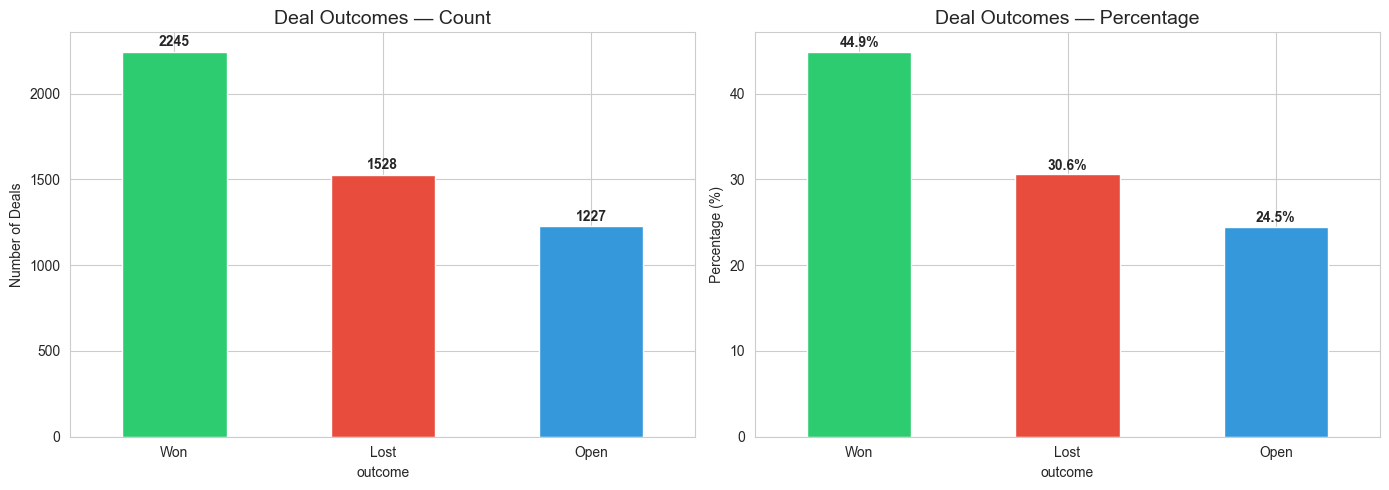


Baseline win rate: 44.9%
→ Our model must beat this to be useful!


In [7]:
# Outcome distribution — bar chart + exact numbers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Count
outcome_counts = deals["outcome"].value_counts()
colors = {"Won": "#2ecc71", "Lost": "#e74c3c", "Open": "#3498db"}
outcome_counts.plot(kind="bar", ax=axes[0], color=[colors[x] for x in outcome_counts.index])
axes[0].set_title("Deal Outcomes — Count", fontsize=14)
axes[0].set_ylabel("Number of Deals")
axes[0].tick_params(axis="x", rotation=0)

# Add value labels on bars
for i, (idx, val) in enumerate(outcome_counts.items()):
    axes[0].text(i, val + 30, str(val), ha="center", fontweight="bold")

# Plot 2: Percentage
outcome_pct = (outcome_counts / len(deals) * 100).round(1)
outcome_pct.plot(kind="bar", ax=axes[1], color=[colors[x] for x in outcome_pct.index])
axes[1].set_title("Deal Outcomes — Percentage", fontsize=14)
axes[1].set_ylabel("Percentage (%)")
axes[1].tick_params(axis="x", rotation=0)

for i, (idx, val) in enumerate(outcome_pct.items()):
    axes[1].text(i, val + 0.5, f"{val}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\nBaseline win rate: {(deals['outcome'] == 'Won').mean():.1%}")
print("→ Our model must beat this to be useful!")

## Step 3: Feature Distributions

**WHY look at distributions?**
- Skewed features may need **log transformation** for some models
- Outliers can dominate model training — need to decide: clip or keep?
- Understanding the "shape" of each feature helps you pick the right model

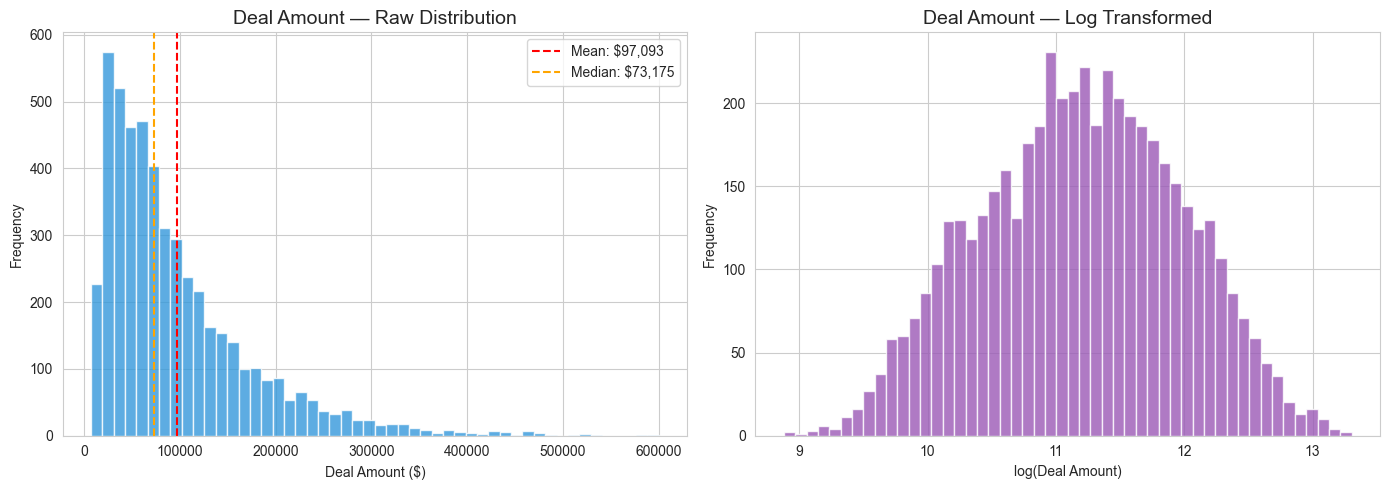

Mean: $97,093  |  Median: $73,175
Skewness: 1.77  (>1 = heavily right-skewed)


In [8]:
# Deal Amount Distribution
# WHAT TO LOOK FOR: Is it skewed? (right-skewed = many small deals, few big ones)
# If heavily skewed → consider log transform for modeling

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(deals["deal_amount"], bins=50, color="#3498db", edgecolor="white", alpha=0.8)
axes[0].set_title("Deal Amount — Raw Distribution", fontsize=14)
axes[0].set_xlabel("Deal Amount ($)")
axes[0].set_ylabel("Frequency")
axes[0].axvline(deals["deal_amount"].mean(), color="red", linestyle="--", label=f'Mean: ${deals["deal_amount"].mean():,.0f}')
axes[0].axvline(deals["deal_amount"].median(), color="orange", linestyle="--", label=f'Median: ${deals["deal_amount"].median():,.0f}')
axes[0].legend()

# Log-transformed — often reveals patterns hidden by skew
axes[1].hist(np.log1p(deals["deal_amount"]), bins=50, color="#9b59b6", edgecolor="white", alpha=0.8)
axes[1].set_title("Deal Amount — Log Transformed", fontsize=14)
axes[1].set_xlabel("log(Deal Amount)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# WHY log transform?
# Mean >> Median means right-skewed. Log transform makes it more symmetric.
# Many ML models (linear regression, neural nets) work better with symmetric distributions.
# Tree-based models (XGBoost) don't care — they split on thresholds, not magnitudes.
print(f"Mean: ${deals['deal_amount'].mean():,.0f}  |  Median: ${deals['deal_amount'].median():,.0f}")
print(f"Skewness: {deals['deal_amount'].skew():.2f}  (>1 = heavily right-skewed)")

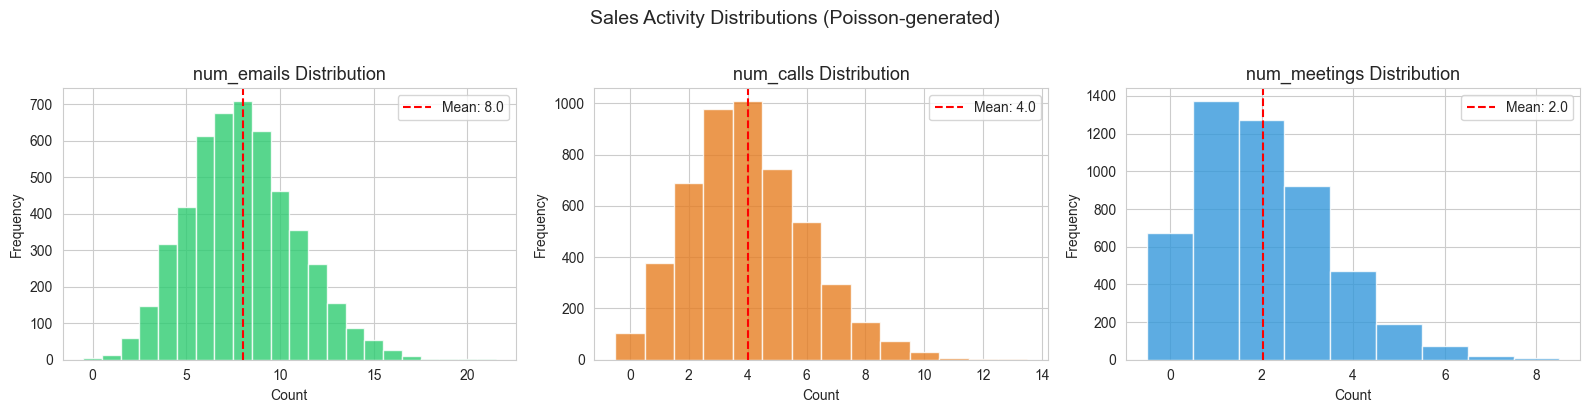

In [9]:
# Activity features distribution (emails, calls, meetings)
# These are our Poisson-generated count features

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, color in zip(axes, ["num_emails", "num_calls", "num_meetings"], 
                            ["#2ecc71", "#e67e22", "#3498db"]):
    ax.hist(deals[col], bins=range(0, deals[col].max() + 2), color=color, 
            edgecolor="white", alpha=0.8, align="left")
    ax.set_title(f"{col} Distribution", fontsize=13)
    ax.set_xlabel("Count")
    ax.set_ylabel("Frequency")
    ax.axvline(deals[col].mean(), color="red", linestyle="--", 
               label=f"Mean: {deals[col].mean():.1f}")
    ax.legend()

plt.suptitle("Sales Activity Distributions (Poisson-generated)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

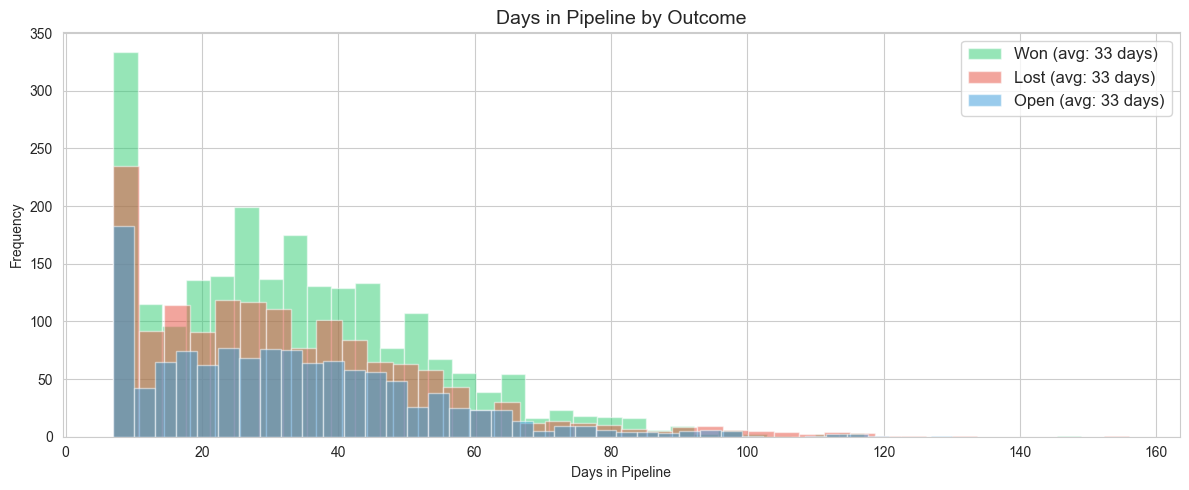

In [10]:
# Days in Pipeline distribution
# WHY care about this? "Time kills deals" — long pipeline = bad sign

fig, ax = plt.subplots(figsize=(12, 5))

# Color by outcome to see the pattern
for outcome, color in [("Won", "#2ecc71"), ("Lost", "#e74c3c"), ("Open", "#3498db")]:
    subset = deals[deals["outcome"] == outcome]
    ax.hist(subset["days_in_pipeline"], bins=40, alpha=0.5, color=color, 
            label=f"{outcome} (avg: {subset['days_in_pipeline'].mean():.0f} days)")

ax.set_title("Days in Pipeline by Outcome", fontsize=14)
ax.set_xlabel("Days in Pipeline")
ax.set_ylabel("Frequency")
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

# KEY INSIGHT: If Won deals have shorter pipeline days than Lost deals,
# that confirms our synthetic data has realistic patterns.

## Step 4: Win Rate by Categorical Features

**WHY?** This is the most important EDA step for classification problems.

We want to see: **Does the win rate change significantly across different categories?**
- If yes → that feature is predictive, the model will use it
- If no → that feature is noise, might not help the model

This is essentially doing manually what the model will do automatically — but understanding it helps you:
1. Validate the model's behavior later ("the model says industry matters — and our EDA confirms it")
2. Catch bugs ("the model says lead source doesn't matter — but our EDA shows it does → something's wrong")

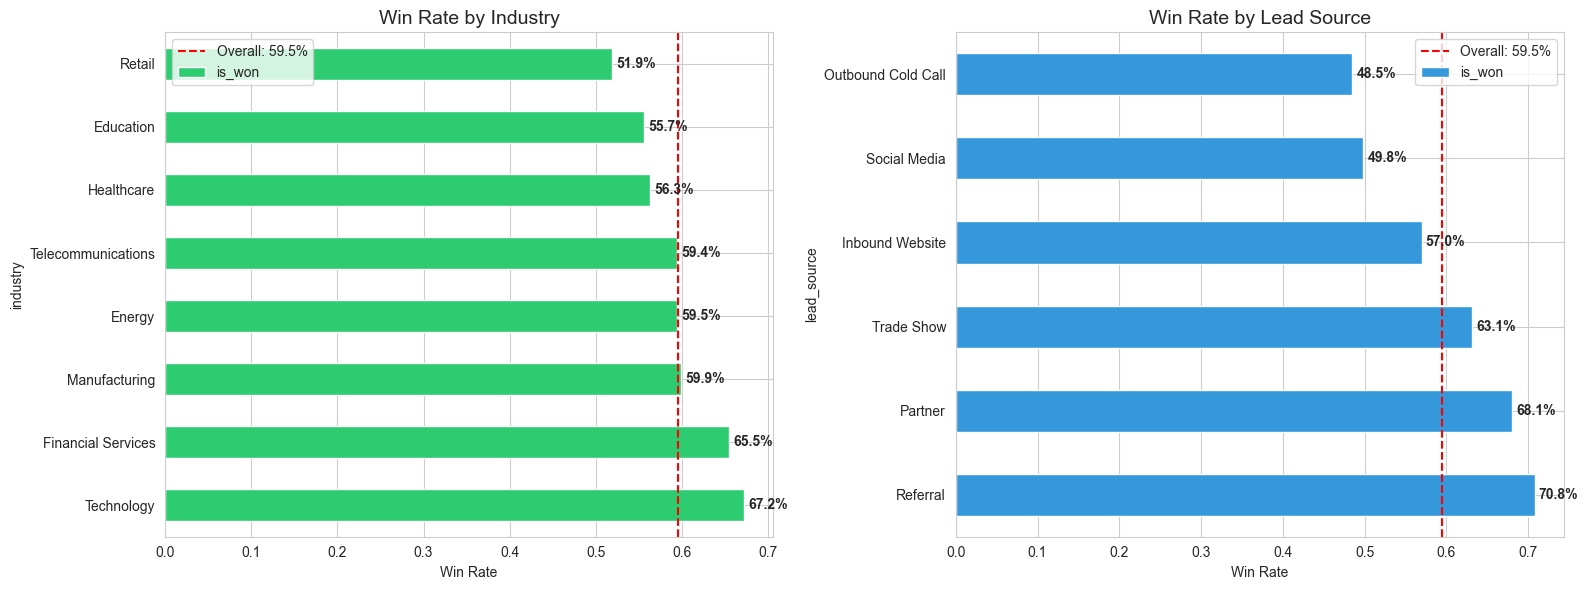

KEY INSIGHT: Referrals should have highest win rate, Cold Calls lowest.
If this matches → our synthetic data has realistic patterns!


In [11]:
# Win Rate by Industry
# Filter to only closed deals (Won or Lost) — Open deals don't have an outcome yet
closed_deals = deals[deals["outcome"].isin(["Won", "Lost"])].copy()
closed_deals["is_won"] = (closed_deals["outcome"] == "Won").astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Win rate by Industry
industry_wr = closed_deals.groupby("industry")["is_won"].mean().sort_values(ascending=False)
industry_wr.plot(kind="barh", ax=axes[0], color="#2ecc71", edgecolor="white")
axes[0].set_title("Win Rate by Industry", fontsize=14)
axes[0].set_xlabel("Win Rate")
axes[0].axvline(closed_deals["is_won"].mean(), color="red", linestyle="--", 
                label=f"Overall: {closed_deals['is_won'].mean():.1%}")
axes[0].legend()

# Add percentage labels
for i, val in enumerate(industry_wr):
    axes[0].text(val + 0.005, i, f"{val:.1%}", va="center", fontweight="bold")

# Win rate by Lead Source
source_wr = closed_deals.groupby("lead_source")["is_won"].mean().sort_values(ascending=False)
source_wr.plot(kind="barh", ax=axes[1], color="#3498db", edgecolor="white")
axes[1].set_title("Win Rate by Lead Source", fontsize=14)
axes[1].set_xlabel("Win Rate")
axes[1].axvline(closed_deals["is_won"].mean(), color="red", linestyle="--",
                label=f"Overall: {closed_deals['is_won'].mean():.1%}")
axes[1].legend()

for i, val in enumerate(source_wr):
    axes[1].text(val + 0.005, i, f"{val:.1%}", va="center", fontweight="bold")

plt.tight_layout()
plt.show()

print("KEY INSIGHT: Referrals should have highest win rate, Cold Calls lowest.")
print("If this matches → our synthetic data has realistic patterns!")

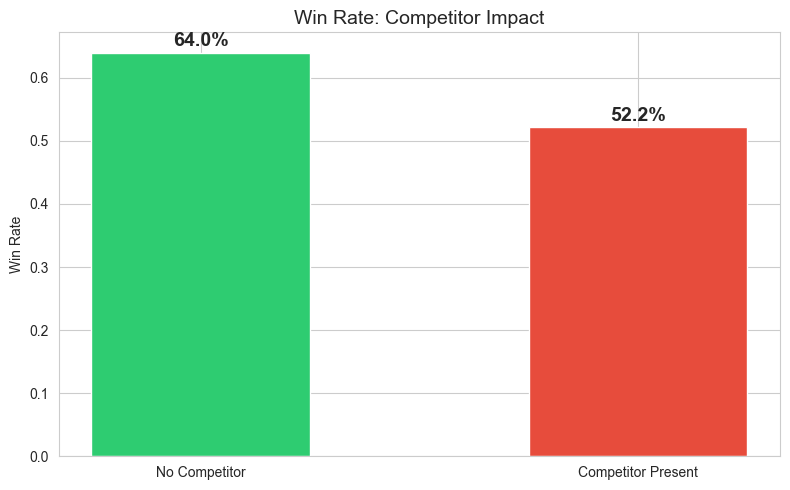

Competitor reduces win rate by 11.8% — significant signal for the model!


In [12]:
# Win Rate: Competitor vs No Competitor
fig, ax = plt.subplots(figsize=(8, 5))

comp_wr = closed_deals.groupby("competitor_involved")["is_won"].mean()
comp_labels = {0: "No Competitor", 1: "Competitor Present"}
bars = ax.bar([comp_labels[k] for k in comp_wr.index], comp_wr.values, 
              color=["#2ecc71", "#e74c3c"], edgecolor="white", width=0.5)

for bar, val in zip(bars, comp_wr.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.1%}", 
            ha="center", fontweight="bold", fontsize=14)

ax.set_title("Win Rate: Competitor Impact", fontsize=14)
ax.set_ylabel("Win Rate")
plt.tight_layout()
plt.show()

diff = comp_wr[0] - comp_wr[1]
print(f"Competitor reduces win rate by {diff:.1%} — significant signal for the model!")

## Step 5: Correlation Analysis

**WHY?**
- Shows which numeric features move together
- High correlation between features = **multicollinearity** — can confuse some models
- High correlation between a feature and the target = **strong predictor**
- Helps you decide which features to keep, drop, or combine

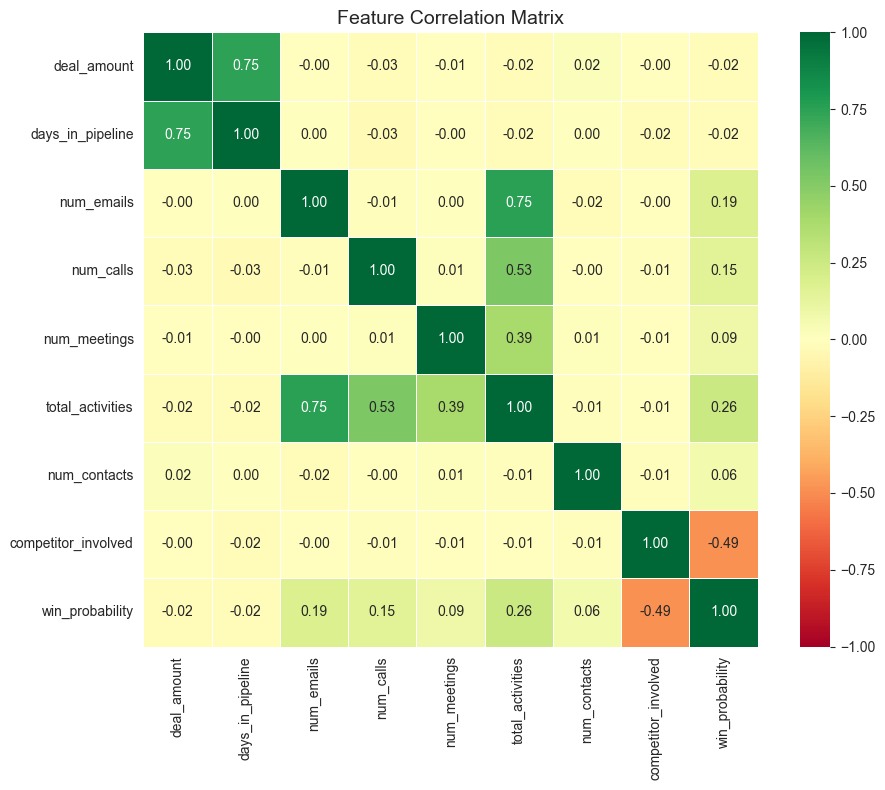

In [13]:
# Correlation Heatmap
# Pick only numeric columns relevant for modeling
numeric_cols = ["deal_amount", "days_in_pipeline", "num_emails", "num_calls", 
                "num_meetings", "total_activities", "num_contacts", 
                "competitor_involved", "win_probability"]

corr_matrix = deals[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1)
ax.set_title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

# WHAT TO LOOK FOR in the heatmap:
# - win_probability row: which features correlate most with winning?
# - num_emails/calls/meetings → total_activities: expected high correlation (it's a sum!)
#   This is called MULTICOLLINEARITY. We might drop the individual cols and keep the total.
# - deal_amount ↔ days_in_pipeline: should be positive (bigger deals take longer)

## Step 6: Deal Amount by Industry (Box Plot)

**WHY box plots?**
- Shows median, spread, and outliers in one chart
- Lets you compare distributions across categories side by side
- Much more informative than just comparing averages

In [14]:
industrydeals = deals.groupby("industry")["deal_amount"]
print(industrydeals.median().sort_values(ascending=False))

industry
Energy                200201.330
Manufacturing         156969.135
Financial Services    100696.250
Healthcare             78303.000
Telecommunications     68262.555
Technology             55800.960
Retail                 32814.260
Education              24178.330
Name: deal_amount, dtype: float64


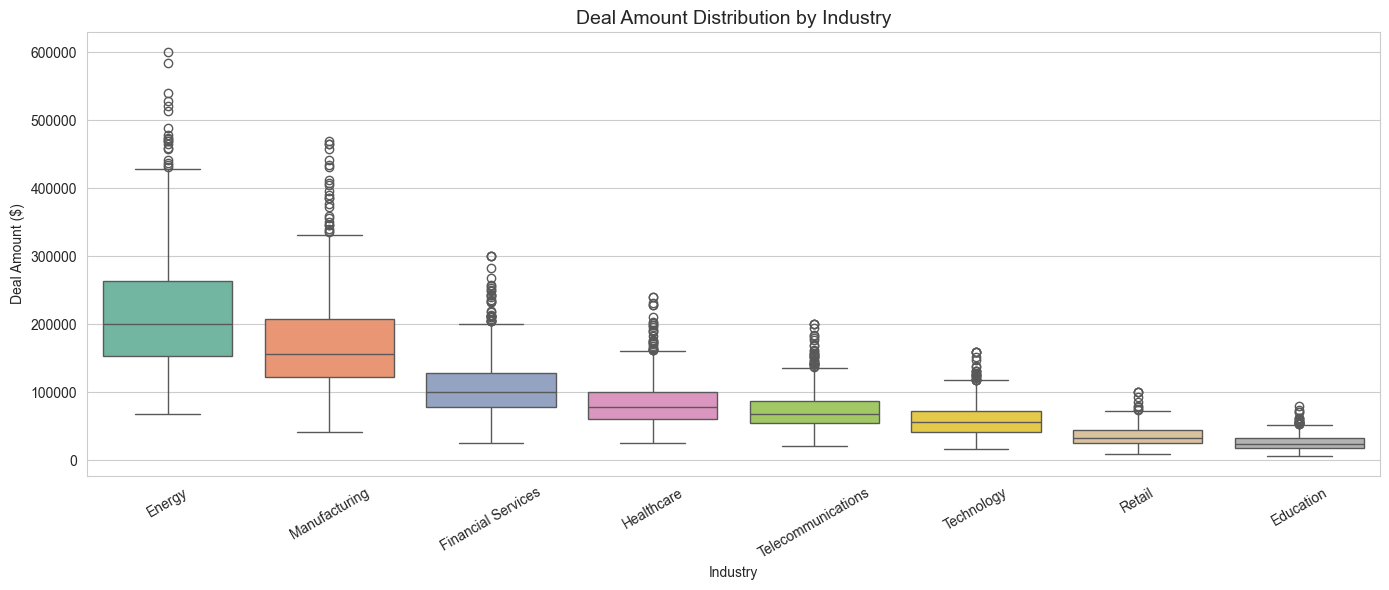

In [15]:
# Box plot: Deal amount by Industry
fig, ax = plt.subplots(figsize=(14, 6))

# Sort industries by median deal size for cleaner visualization
industry_order = deals.groupby("industry")["deal_amount"].median().sort_values(ascending=False).index

sns.boxplot(data=deals, x="industry", y="deal_amount", order=industry_order,
            palette="Set2", ax=ax)
ax.set_title("Deal Amount Distribution by Industry", fontsize=14)
ax.set_xlabel("Industry")
ax.set_ylabel("Deal Amount ($)")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# HOW TO READ A BOX PLOT:
# - Box = 25th to 75th percentile (middle 50% of data)
# - Line inside box = median
# - Whiskers = extend to 1.5x the box height
# - Dots beyond whiskers = outliers

## Step 7: Activity vs Outcome (The Most Important Feature?)

**WHY?** In our data generator, we made `total_activities` the strongest positive signal. Let's verify the model will have something to learn.

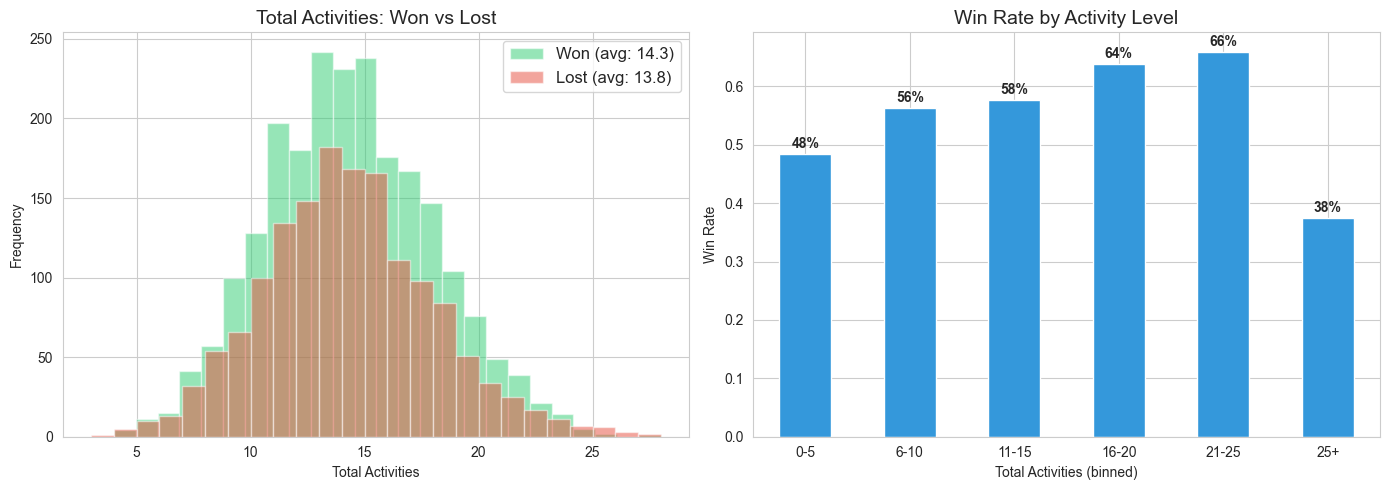

EXPECTED: Win rate should increase with more activities.
This confirms: engaged prospects buy — the #1 predictor in real CRM analytics.


In [16]:
# Total Activities: Won vs Lost
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution comparison
for outcome, color in [("Won", "#2ecc71"), ("Lost", "#e74c3c")]:
    subset = closed_deals[closed_deals["outcome"] == outcome]
    axes[0].hist(subset["total_activities"], bins=25, alpha=0.5, color=color,
                 label=f'{outcome} (avg: {subset["total_activities"].mean():.1f})')

axes[0].set_title("Total Activities: Won vs Lost", fontsize=14)
axes[0].set_xlabel("Total Activities")
axes[0].set_ylabel("Frequency")
axes[0].legend(fontsize=12)

# Win rate by activity bins
# WHY bin? Raw activity count is noisy. Grouping into bins shows the trend.
closed_deals["activity_bin"] = pd.cut(closed_deals["total_activities"], 
                                       bins=[0, 5, 10, 15, 20, 25, 50],
                                       labels=["0-5", "6-10", "11-15", "16-20", "21-25", "25+"])
bin_wr = closed_deals.groupby("activity_bin", observed=True)["is_won"].mean()
bin_wr.plot(kind="bar", ax=axes[1], color="#3498db", edgecolor="white")
axes[1].set_title("Win Rate by Activity Level", fontsize=14)
axes[1].set_xlabel("Total Activities (binned)")
axes[1].set_ylabel("Win Rate")
axes[1].tick_params(axis="x", rotation=0)

for i, val in enumerate(bin_wr):
    axes[1].text(i, val + 0.01, f"{val:.0%}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print("EXPECTED: Win rate should increase with more activities.")
print("This confirms: engaged prospects buy — the #1 predictor in real CRM analytics.")

## Step 8: Revenue Time Series

**WHY?** This is the data we'll use for the **forecasting model** (Prophet/LSTM) — predicting future monthly revenue. Let's see if there are trends or seasonality.

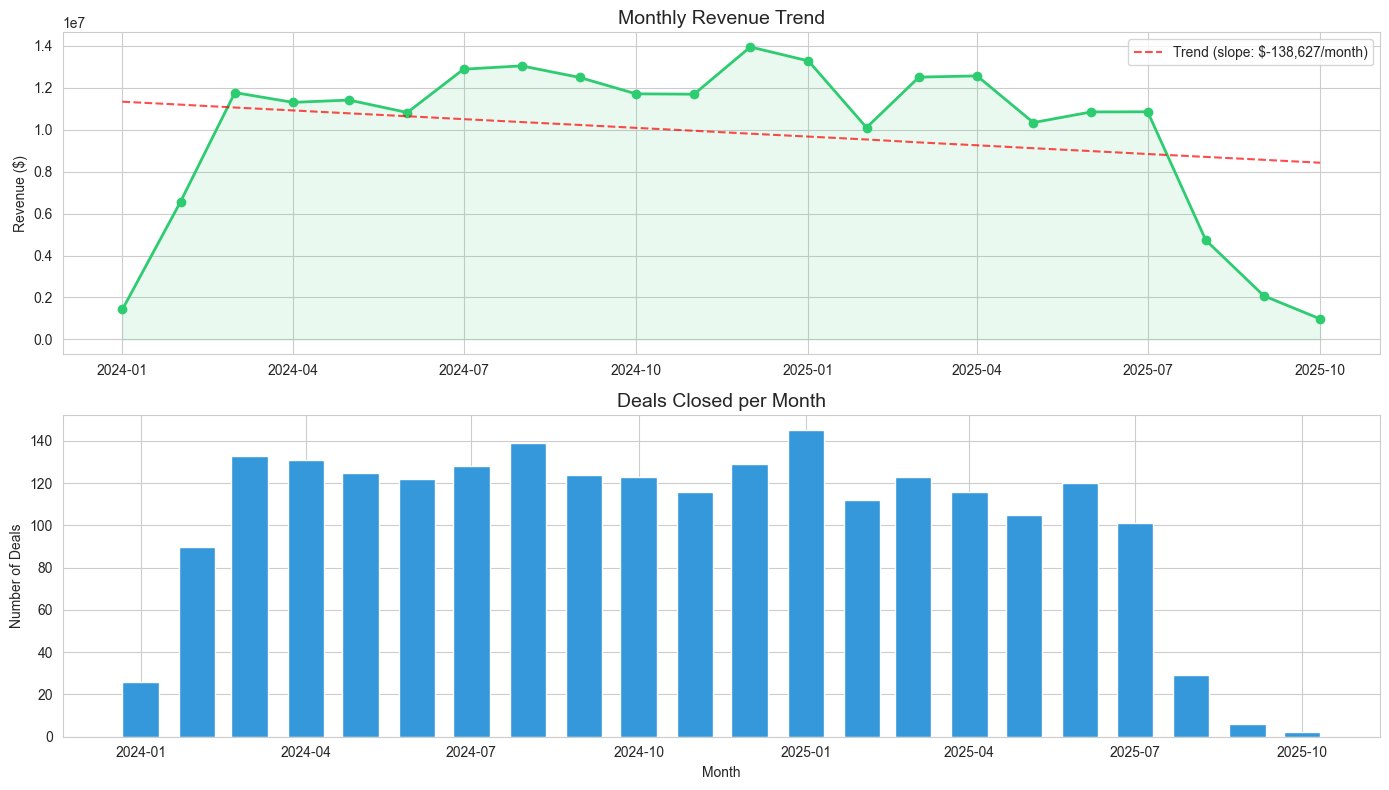

Total revenue (18 months): $217,457,973
Average monthly revenue: $9,884,453
Trend: Declining at $138,627/month


In [17]:
# Monthly Revenue Trend
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Revenue over time
axes[0].plot(revenue["date"], revenue["revenue"], marker="o", color="#2ecc71", 
             linewidth=2, markersize=6)
axes[0].fill_between(revenue["date"], revenue["revenue"], alpha=0.1, color="#2ecc71")
axes[0].set_title("Monthly Revenue Trend", fontsize=14)
axes[0].set_ylabel("Revenue ($)")
# Add trend line
z = np.polyfit(range(len(revenue)), revenue["revenue"], 1)
p = np.poly1d(z)
axes[0].plot(revenue["date"], p(range(len(revenue))), "--", color="red", 
             alpha=0.7, label=f"Trend (slope: ${z[0]:,.0f}/month)")
axes[0].legend()

# Plot 2: Deals closed per month
axes[1].bar(revenue["date"], revenue["deals_closed"], color="#3498db", 
            edgecolor="white", width=20)
axes[1].set_title("Deals Closed per Month", fontsize=14)
axes[1].set_ylabel("Number of Deals")
axes[1].set_xlabel("Month")

plt.tight_layout()
plt.show()

print(f"Total revenue (18 months): ${revenue['revenue'].sum():,.0f}")
print(f"Average monthly revenue: ${revenue['revenue'].mean():,.0f}")
print(f"Trend: {'Growing' if z[0] > 0 else 'Declining'} at ${abs(z[0]):,.0f}/month")

## Step 9: Sales Rep Performance

**WHY?** In a real sales org, rep performance varies widely. This could be a feature, or it could be a source of bias (a "good" rep might just have better territories).

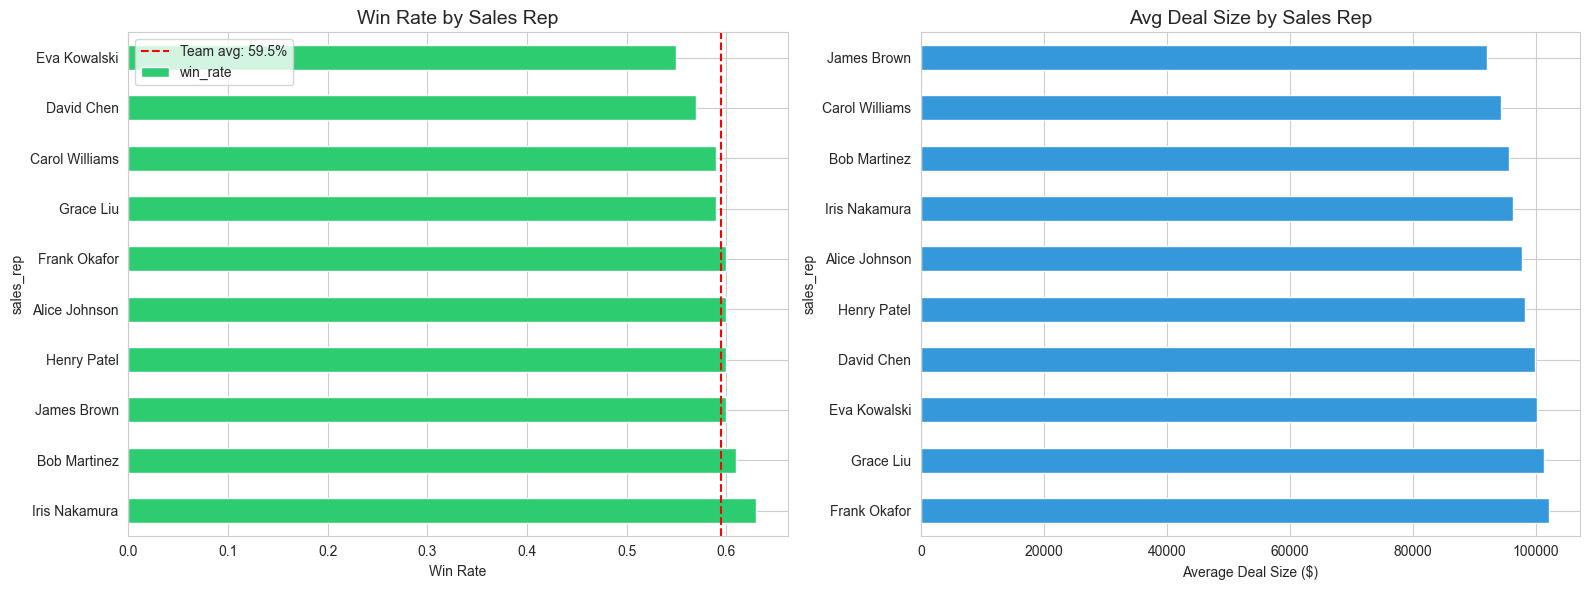


Sales Rep Scorecard:
                total_deals  win_rate  avg_deal_size  total_revenue
sales_rep                                                          
Iris Nakamura           371      0.63       96339.96    21676259.86
Bob Martinez            401      0.61       95610.65    24062274.13
James Brown             347      0.60       91999.54    18831957.69
Henry Patel             369      0.60       98297.03    21579221.03
Alice Johnson           386      0.60       97769.85    22795067.02
Frank Okafor            385      0.60      102090.35    23647828.74
Grace Liu               387      0.59      101380.85    23419847.72
Carol Williams          370      0.59       94341.54    21518397.75
David Chen              389      0.57       99835.88    21921442.13
Eva Kowalski            368      0.55      100223.90    18005676.79


In [18]:
# Sales Rep Scorecard
rep_stats = closed_deals.groupby("sales_rep").agg(
    total_deals=("deal_id", "count"),
    win_rate=("is_won", "mean"),
    avg_deal_size=("deal_amount", "mean"),
    total_revenue=("deal_amount", lambda x: x[closed_deals.loc[x.index, "is_won"] == 1].sum()),
).sort_values("win_rate", ascending=False).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Win rate by rep
rep_stats["win_rate"].plot(kind="barh", ax=axes[0], color="#2ecc71", edgecolor="white")
axes[0].set_title("Win Rate by Sales Rep", fontsize=14)
axes[0].set_xlabel("Win Rate")
axes[0].axvline(closed_deals["is_won"].mean(), color="red", linestyle="--", 
                label=f"Team avg: {closed_deals['is_won'].mean():.1%}")
axes[0].legend()

# Avg deal size by rep
rep_stats.sort_values("avg_deal_size", ascending=False)["avg_deal_size"].plot(
    kind="barh", ax=axes[1], color="#3498db", edgecolor="white")
axes[1].set_title("Avg Deal Size by Sales Rep", fontsize=14)
axes[1].set_xlabel("Average Deal Size ($)")

plt.tight_layout()
plt.show()

print("\nSales Rep Scorecard:")
print(rep_stats.to_string())

## Step 10: Simpson's Paradox — Sales Rep Performance is Misleading!

**The problem:** Eva has the lowest win rate (55%). Is she the worst rep?

**Not so fast.** Eva also handles bigger deals, which are inherently harder to close.
If we compare reps **within the same deal size range**, the story might flip.

This is called **Simpson's Paradox** — aggregated data can tell the **opposite** story from segmented data.

**WHY this matters for ML:**
- If the model uses `sales_rep` as a feature, it might learn "Eva = bad" — which is WRONG
- The model needs to capture the **interaction** between rep and deal size
- This is why feature engineering and understanding your data > just throwing everything into a model

In [ ]:
# ============================================================
# Segmented Analysis: Win Rate by Sales Rep WITHIN Deal Size Buckets
# ============================================================
# WHY? Overall win rate is misleading because it ignores deal difficulty.
# A rep closing 50% of $200K deals is better than one closing 60% of $20K deals.

# Step 1: Create deal size buckets
closed_deals["deal_size_bucket"] = pd.cut(
    closed_deals["deal_amount"],
    bins=[0, 50_000, 100_000, 150_000, float("inf")],
    labels=["Small (<$50K)", "Medium ($50-100K)", "Large ($100-150K)", "Enterprise ($150K+)"]
)

# Step 2: Calculate win rate per rep per bucket
segmented = closed_deals.groupby(
    ["sales_rep", "deal_size_bucket"], observed=True
)["is_won"].agg(["mean", "count"]).reset_index()
segmented.columns = ["sales_rep", "deal_size_bucket", "win_rate", "num_deals"]

# Step 3: Pivot for a clean comparison table
pivot = segmented.pivot(index="sales_rep", columns="deal_size_bucket", values="win_rate")
pivot = pivot.round(3)

# Also get overall win rate for comparison
overall_wr = closed_deals.groupby("sales_rep")["is_won"].mean().round(3)
pivot["Overall"] = overall_wr

print("Win Rate by Sales Rep x Deal Size:")
print("=" * 80)
print(pivot.to_string())
print("\n")

# Step 4: Visualize it
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap of segmented win rates
sns.heatmap(pivot.drop(columns=["Overall"]), annot=True, fmt=".0%", cmap="RdYlGn",
            center=0.5, linewidths=1, ax=axes[0], vmin=0.3, vmax=0.8)
axes[0].set_title("Win Rate: Sales Rep x Deal Size\n(Simpson's Paradox Check)", fontsize=13)
axes[0].set_ylabel("")

# Bar chart: compare overall vs enterprise win rate
comparison = pd.DataFrame({
    "Overall Win Rate": overall_wr,
    "Enterprise ($150K+) Win Rate": pivot["Enterprise ($150K+)"]
}).sort_values("Overall Win Rate", ascending=True)

comparison.plot(kind="barh", ax=axes[1], color=["#3498db", "#e74c3c"], edgecolor="white")
axes[1].set_title("Overall vs Enterprise Win Rate per Rep", fontsize=13)
axes[1].set_xlabel("Win Rate")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# Step 5: Find Simpson's Paradox cases
print("\nSimpson's Paradox Check:")
print("-" * 50)
enterprise_wr = pivot["Enterprise ($150K+)"].sort_values(ascending=False)
overall_sorted = overall_wr.sort_values(ascending=False)

print(f"\nTop 3 by OVERALL win rate:     {list(overall_sorted.head(3).index)}")
print(f"Top 3 by ENTERPRISE win rate:  {list(enterprise_wr.head(3).index)}")
print(f"\nIf these lists differ -> Simpson's Paradox is present!")
print(f"-> Overall ranking is MISLEADING without controlling for deal size.")

## Step 10: Key Takeaways & Next Steps

Summarize what we learned and how it informs model building.

In [20]:
# ============================================================
# SUMMARY — Print key findings
# ============================================================
print("=" * 60)
print("EDA SUMMARY — Key Findings")
print("=" * 60)

print(f"""
DATASET:
  - {len(deals)} total deals, {len(closed_deals)} closed (Won/Lost)
  - {(deals['outcome'] == 'Open').sum()} still open in pipeline
  - No missing values (clean synthetic data)

TARGET VARIABLE:
  - Baseline win rate: {closed_deals['is_won'].mean():.1%}
  - Classes are roughly balanced → no need for oversampling

STRONGEST PREDICTORS (from visual analysis):
  1. Total Activities — higher activity = higher win rate
  2. Competitor Involved — reduces win rate significantly
  3. Lead Source — Referrals best, Cold Calls worst
  4. Deal Amount — larger deals are harder to close
  5. Days in Pipeline — longer = lower win rate

FEATURE ENGINEERING IDEAS for modeling:
  - Use total_activities instead of individual email/call/meeting counts
  - Log-transform deal_amount (right-skewed)
  - Encode deal_stage as ordinal (stage order matters)
  - One-hot encode industry and lead_source
  - Consider interaction: deal_amount x competitor_involved

NEXT STEPS:
  → Week 2: Build XGBoost deal scoring model
  → Week 2: Build Prophet revenue forecasting model
""")
print("=" * 60)

EDA SUMMARY — Key Findings

DATASET:
  - 5000 total deals, 3773 closed (Won/Lost)
  - 1227 still open in pipeline
  - No missing values (clean synthetic data)

TARGET VARIABLE:
  - Baseline win rate: 59.5%
  - Classes are roughly balanced → no need for oversampling

STRONGEST PREDICTORS (from visual analysis):
  1. Total Activities — higher activity = higher win rate
  2. Competitor Involved — reduces win rate significantly
  3. Lead Source — Referrals best, Cold Calls worst
  4. Deal Amount — larger deals are harder to close
  5. Days in Pipeline — longer = lower win rate

FEATURE ENGINEERING IDEAS for modeling:
  - Use total_activities instead of individual email/call/meeting counts
  - Log-transform deal_amount (right-skewed)
  - Encode deal_stage as ordinal (stage order matters)
  - One-hot encode industry and lead_source
  - Consider interaction: deal_amount x competitor_involved

NEXT STEPS:
  → Week 2: Build XGBoost deal scoring model
  → Week 2: Build Prophet revenue forecastin